# Chicken-heart development

Calculate populations between D4, D7, D10, and D14, then evaluate their growth
rates. The two plots follow the analyses in Supplementary Fig. S9: median
growth by cell type and growth mapped onto the tissue coordinates.

The calculation starts from the trained model, not from a growth table or an
image. The simulation is stochastic. Newly generated populations need not be
identical to the population used to prepare the printed figure.

## Prepare the data and model

Follow [installation](../../installation.md), then extract
`chicken_heart_model.zip` and `chicken_heart_analysis_data.zip` from the
[data page](../../data_checkpoints.md) into your project directory.
The model archive contains the cell-type classifier as well as the dynamical
model. No raw-data archive is needed for this analysis.

Set `PROJECT_DIR` to that directory. Run the notebook from the source checkout.
For model fitting, see [Train a model](../../training.md).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import torch
import yaml

import os
REPO_ROOT = Path(os.environ.get("CYTOBRIDGE_SOURCE_DIR", ".")).resolve()
PROJECT_DIR = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
DATA_DIR = PROJECT_DIR / "data" / "chicken_heart"
sys.path.insert(0, str(REPO_ROOT / "reproduction" / "chicken_heart"))
ANALYSIS_ROOT = Path(os.environ.get("CYTOBRIDGE_HEART_OUTPUT_DIR", PROJECT_DIR / "outputs" / "chicken_heart_paper")).resolve()
CELLTYPE_SHARE_ROOT = DATA_DIR
import CytoBridge as cb
PACKAGE_ROOT = Path(cb.__file__).resolve().parents[1]

if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

import CytoBridge as cb

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"Repo root: {REPO_ROOT}")

In [2]:
WORKFLOW_CONFIG_PATH = DATA_DIR / "workflow.json"
ALIGNED_H5AD_PATH = DATA_DIR / "aligned.h5ad"
MODEL_DIR = DATA_DIR / "model"
EDGE_PREDICTOR_PATH = DATA_DIR / "edge_classifier" / "chicken_heart_edge_model.pt"
OUTPUT_DIR = ANALYSIS_ROOT / "new_runs_formal_trained" / "formal_daily_piecewise_interpolation_celltypecorrected"
SLICE_DIR = OUTPUT_DIR / "slice_data"
COMM_DIR = OUTPUT_DIR / "communication_slice_data"
CLASSIFIER_CACHE_PATH = DATA_DIR / "classifier_cache" / "classifier_resmlp_432f09f20ff65c0d.pt"
if not CLASSIFIER_CACHE_PATH.is_file():
    raise FileNotFoundError(CLASSIFIER_CACHE_PATH)

for path in (OUTPUT_DIR, SLICE_DIR, COMM_DIR):
    path.mkdir(parents=True, exist_ok=True)

with WORKFLOW_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    workflow_config = json.load(handle)

annotation_key = workflow_config["dataset"]["annotation_key"]
time_key = workflow_config["dataset"]["time_key"]
obsm_key = workflow_config["dataset"]["obsm_key"]
spatial_key = workflow_config["dataset"]["spatial_key"]
concat_spatial = bool(workflow_config["dataset"].get("concat_spatial", True))

observed_times = [float(value) for value in workflow_config["downstream"]["observed"]]
interp_time_points = [
    1.0 / 3.0,
    2.0 / 3.0,
    4.0 / 3.0,
    5.0 / 3.0,
    2.25,
    2.50,
    2.75,
]
requested_plot_points = sorted(observed_times + interp_time_points)

# The formal workflow requires every requested split-SDE output time to lie
# on the fixed split-event grid. The daily points here mix thirds and quarters,
# so we use 1/12 as the shared output-event spacing.
formal_split_sde_dt = float(workflow_config["downstream"]["split_sde_dt"])
formal_split_resample_dt = float(workflow_config["downstream"]["split_resample_dt"])
daily_split_output_grid_dt = 1.0 / 12.0

time_label_map = {
    0.0: "D4",
    round(1.0 / 3.0, 9): "D5",
    round(2.0 / 3.0, 9): "D6",
    1.0: "D7",
    round(4.0 / 3.0, 9): "D8",
    round(5.0 / 3.0, 9): "D9",
    2.0: "D10",
    2.25: "D11",
    2.50: "D12",
    2.75: "D13",
    3.0: "D14",
}

print("Observed times:", observed_times)
print("Interpolated times:", interp_time_points)
print("Formal split_sde_dt:", formal_split_sde_dt)
print("Formal split_resample_dt:", formal_split_resample_dt)
print("Daily split output grid dt:", daily_split_output_grid_dt)
print("Output dir:", OUTPUT_DIR)
print("Corrected package root:", PACKAGE_ROOT)
print("Corrected classifier cache:", CLASSIFIER_CACHE_PATH)

## Load the observed states and trained model

`adata_to_aligned_dataframe` reads the existing aligned coordinates and PCA
features, in the order used for training. `load_dynamical_model_from_dir`
loads the trained model. Neither function fits a new PCA or model.

In [3]:
adata = ad.read_h5ad(ALIGNED_H5AD_PATH)
if annotation_key not in adata.obs.columns:
    raise KeyError(
        f"Expected annotation column '{annotation_key}' in adata.obs, "
        f"but only found: {list(adata.obs.columns)}"
    )

df, resolved_time_key = cb.tl.adata_to_aligned_dataframe(
    adata,
    time_key=time_key,
    obsm_key=obsm_key,
    spatial_key=spatial_key,
    concat_spatial=concat_spatial,
    annotation_key=annotation_key,
)
feature_cols = cb.tl.infer_feature_columns(df, annotation_column=annotation_key)
dim = len(feature_cols)

loaded = cb.tl.load_dynamical_model_from_dir(
    MODEL_DIR,
    dim=dim,
    device=DEVICE,
    edge_predictor_path=EDGE_PREDICTOR_PATH,
)
runtime = cb.tl.build_dynamical_runtime(loaded)

print(f"Resolved time key: {resolved_time_key}")
print(f"Feature dimension: {dim}")
print(f"Loaded weight stage: {loaded.weight_stage}")
print(f"Loaded score stage: {loaded.score_stage}")
display(df.head())

,samples,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x45,x46,x47,x48,x49,x50,x51,x52,cell_id,celltype_prediction
AACAGGAAATCGAATA-1_D4,0.0,-0.309582,0.220557,-10.376935,1.810453,-5.053881,0.157362,2.951980,-1.235983,-0.520813,...,-0.364734,0.875380,-0.462932,-0.658076,-0.105274,-0.771484,-0.656299,0.046606,AACAGGAAATCGAATA-1_D4,Valve cells
AACGATAGAAGGGCCG-1_D4,0.0,0.006353,0.207816,-8.713023,-2.729383,-1.787431,3.782014,5.170138,0.780732,1.639771,...,-0.123157,-0.005581,0.050086,0.210115,-0.017330,-0.584068,-0.395630,-0.367514,AACGATAGAAGGGCCG-1_D4,Immature myocardial cells
AACTGATATTAGGCCT-1_D4,0.0,-0.288070,0.175535,-11.920918,2.214181,-4.386878,0.379891,3.459870,-2.080261,-0.486692,...,-0.391057,-0.130964,-0.065138,-0.180685,0.159552,-0.419743,-0.947490,-0.253913,AACTGATATTAGGCCT-1_D4,Valve cells
AACTGGGTCCCGACGT-1_D4,0.0,-0.295561,-0.019695,-6.501947,-4.517496,-2.937674,1.972710,2.348546,0.875312,2.365091,...,0.559212,0.371529,0.062954,-0.665720,-0.468693,0.690836,0.562529,-0.054594,AACTGGGTCCCGACGT-1_D4,Immature myocardial cells
AAGTAGAAGACCGGGT-1_D4,0.0,0.168691,0.021806,-6.712903,-5.129903,-2.965898,1.379184,3.778776,1.729583,1.552025,...,0.069265,-0.526332,-0.381194,-0.392580,-0.465705,0.360981,-0.434369,-0.352508,AAGTAGAAGACCGGGT-1_D4,Immature myocardial cells


## Simulate the intervening days

`run_interpolation_workflow` propagates each measured population until the
next measured stage. It generates D5–D6 from D4, D8–D9 from D7, and D11–D13
from D10. The measured populations themselves are retained at D4, D7, D10,
and D14. The classifier assigns cell types to generated cells.

`result.adata_dict` contains these populations, with one AnnData per time.
Its `X` contains the two spatial coordinates followed by the 50 PCA features.
Growth-dependent division and removal are included in the simulation.

In [4]:
downstream_cfg = workflow_config["downstream"]
scientific_cfg = workflow_config["scientific"]

result = cb.tl.run_interpolation_workflow(
    df=df,
    dim=dim,
    annotation_key=annotation_key,
    runtime=runtime,
    device=DEVICE,
    output_dir=str(OUTPUT_DIR),
    requested_plot_points=requested_plot_points,
    interp_time_points=interp_time_points,
    max_observed_timepoints=len(observed_times),
    use_real_for_observed=True,
    classifier_cache_path=str(CLASSIFIER_CACHE_PATH),
    classifier_cache_dir=str(CLASSIFIER_CACHE_PATH.parent),
    classifier_adata=adata,
    classifier_time_key=resolved_time_key,
    classifier_obsm_key=obsm_key,
    classifier_spatial_key=spatial_key,
    classifier_concat_spatial=concat_spatial,
    classifier_epochs=int(downstream_cfg["classifier_epochs"]),
    classifier_hidden_size=int(downstream_cfg["classifier_hidden_size"]),
    classifier_lr=float(downstream_cfg["classifier_lr"]),
    classifier_best_metric=str(downstream_cfg["classifier_best_metric"]),
    classifier_strict_stratification=bool(downstream_cfg["classifier_strict_stratification"]),
    classifier_knn_neighbors=int(scientific_cfg["classifier_k"]),
    sde_n_samples=int(downstream_cfg["sde_n_samples"]),
    sde_dt=float(downstream_cfg["sde_dt"]),
    split_sde_dt=formal_split_sde_dt,
    split_sigma_scalar=float(downstream_cfg["split_sigma"]),
    split_daughter_noise_std=float(downstream_cfg["split_daughter_noise_std"]),
    split_growth_alpha=float(downstream_cfg["split_growth_alpha"]),
    split_interaction_m=1024,
    split_resample_dt=daily_split_output_grid_dt,
    split_max_particles=int(downstream_cfg["split_max_particles"]),
    split_sde_piecewise=bool(downstream_cfg["split_sde_piecewise"]),
    split_sde_piecewise_include_end=bool(downstream_cfg["split_sde_piecewise_include_end"]),
    piecewise_observed_sample_mode=str(downstream_cfg["piecewise_observed_sample_mode"]),
    spatial_warp_to_observed=False,
    spatial_warp_to_observed_piecewise=False,
    spatial_warp_visualization_only=False,
    random_seed=int(scientific_cfg["seed"]),
)

print("Simulation time grid:", result.ts_points)
print("Observed time points:", result.observed_time_points)
print("Interpolated time points:", result.interp_points)

## Evaluate growth on each population

The growth network is evaluated on every cell, using its model state and
time. `growth` contains those per-cell values, their labels, and coordinates.

In [5]:
import matplotlib.pyplot as plt
from downstream_helpers.heart import HEART_LABEL_TO_COLOR

plt.rcParams.update({
    "font.family": "Arial", "font.size": 9, "text.color": "black",
    "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
    "pdf.fonttype": 42, "svg.fonttype": "none",
})
time_order = [time_label_map[round(float(t), 9)] for t in result.ts_points]
slices = {label: result.adata_dict[str(float(t))]
          for label, t in zip(time_order, result.ts_points)}
growth = cb.tl.evaluate_growth_by_timepoint(
    slices, loaded.model, time_points=result.ts_points, time_keys=time_order,
    annotation_key="celltype_prediction", device=DEVICE,
)
growth.to_csv(OUTPUT_DIR / "growth_by_cell.csv", index=False)
growth.head()

,time,time_key,cell_index,x,y,growth,celltype
0,0.0,D4,0,-0.309582,0.220557,0.787985,Valve cells
1,0.0,D4,1,0.006353,0.207816,2.210886,Immature myocardial cells
2,0.0,D4,2,-0.288070,0.175535,0.948449,Valve cells
3,0.0,D4,3,-0.295561,-0.019695,1.824738,Immature myocardial cells
4,0.0,D4,4,0.168691,0.021806,2.370483,Immature myocardial cells


## Median growth by cell type — S9a

Group cells by type and day, take the median growth value, and arrange the
result into a cell-type-by-day table. Rows are ordered by their mean across
the available days. A blank entry means that cell type was absent at that
time, not that its growth was zero. Dashed boxes mark generated stages.

In [6]:
median_growth = growth.groupby(["celltype", "time_key"], observed=True)["growth"].median().unstack()
median_growth = median_growth.reindex(columns=time_order)
median_growth = median_growth.loc[median_growth.mean(axis=1).sort_values(ascending=False).index]
median_growth.to_csv(OUTPUT_DIR / "median_growth_by_celltype.csv")
median_growth

time_key,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14
celltype,,,,,,,,,,,
Macrophages,NaN,NaN,NaN,1.934800,1.944004,2.072258,2.549381,2.482472,2.701549,3.406941,2.876850
Fibroblast cells,NaN,NaN,NaN,2.236865,2.362187,2.590276,0.770952,0.851611,0.958193,1.096999,0.918879
Epi-epithelial cells,2.314904,1.833449,1.363768,0.829713,0.751763,0.806202,0.816867,0.878220,1.027211,1.182663,1.036305
Cardiomyocytes-2,NaN,1.437790,0.922277,0.840674,1.082442,0.557957,NaN,NaN,NaN,NaN,1.860859
TMSB4X high cells,2.298470,NaN,NaN,NaN,NaN,NaN,0.700375,0.835042,0.910208,1.021723,0.906376
Mural cells,NaN,NaN,NaN,NaN,NaN,NaN,1.153465,1.083138,0.997053,1.126129,1.170398
Immature myocardial cells,2.226629,1.781836,1.224705,0.836431,0.708215,0.724268,0.725074,0.798269,0.881633,0.998434,0.921125
Endocardial cells,2.021924,1.471869,1.061288,0.903109,0.739811,0.707947,0.729015,0.756099,0.871990,0.939854,1.045867
Cardiomyocytes-1,1.506790,1.525315,1.058934,0.890349,0.723095,0.764637,0.787186,0.860115,0.943083,1.048714,0.940386


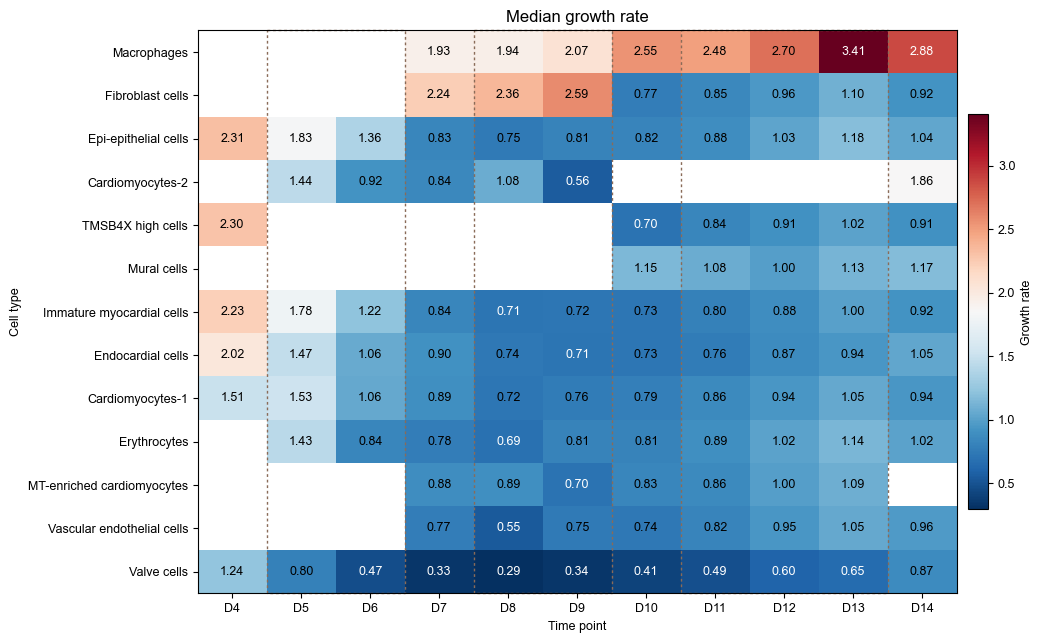

In [7]:
ax = cb.pl.plot_growth_heatmap(
    median_growth, observed_times=["D4", "D7", "D10", "D14"],
)
ax.figure.set_size_inches(10.5, 6.5)
ax.figure.tight_layout()
ax.figure.savefig(OUTPUT_DIR / "growth_heatmap.pdf", bbox_inches="tight")
ax.figure.savefig(OUTPUT_DIR / "growth_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial growth maps — S9b

Plot the same per-cell growth values on the tissue coordinates. Colour
denotes cell type. Point area and opacity increase linearly with growth,
using one scale across all days. These maps do not involve another model
evaluation.

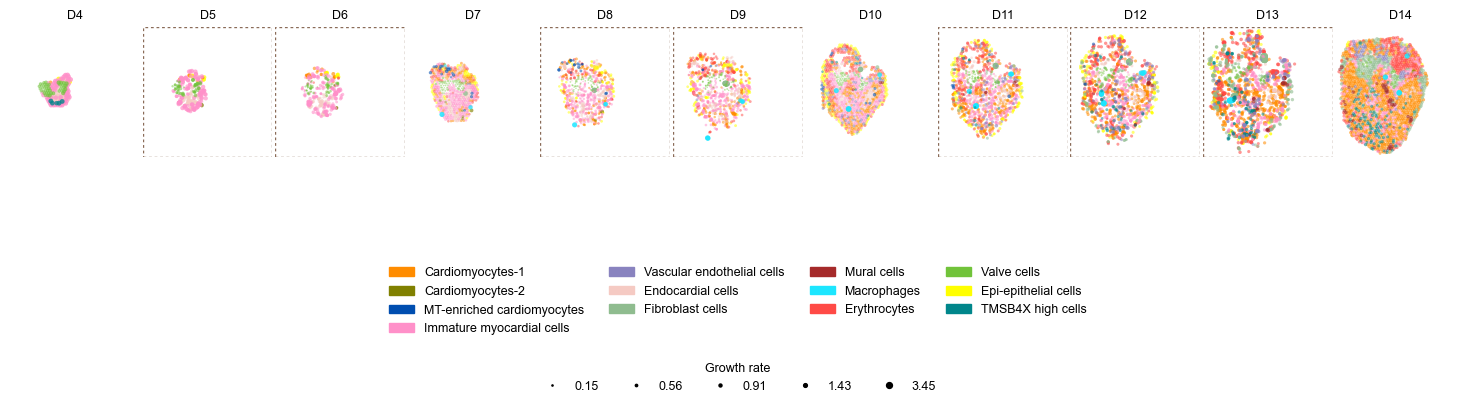

In [8]:
fig, axes = cb.pl.plot_growth_size_maps(
    growth, palette=HEART_LABEL_TO_COLOR, time_order=time_order,
    observed_times=["D4", "D7", "D10", "D14"],
)
fig.savefig(OUTPUT_DIR / "growth_spatial_maps.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "growth_spatial_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## Save the populations

Save one H5AD per day for the lineage and velocity notebooks. The spatial
and communication populations are saved separately, as returned by the
simulation. `manifest.json` records which files belong to each day.

In [9]:
slice_records = []
for time, label in zip(result.ts_points, time_order):
    key = str(float(time))
    slug = f"{float(time):.9f}".rstrip("0").rstrip(".").replace(".", "p")
    record = {
        "time_float": float(time), "time_key": key, "time_label": label,
        "is_observed": label in {"D4", "D7", "D10", "D14"},
    }
    for populations, directory, field in (
        (result.adata_dict, SLICE_DIR, "slice_h5ad"),
        (result.communication_adata_dict, COMM_DIR, "communication_h5ad"),
    ):
        population = populations[key].copy()
        for name in ("time_float", "time_label", "is_observed"):
            population.obs[name] = record[name]
            population.uns[name] = record[name]
        path = directory / f"time_{slug}.h5ad"
        population.write_h5ad(path)
        record[field] = str(path)
    population = result.adata_dict[key]
    record.update(
        n_cells=population.n_obs,
        slice_origin=population.uns["slice_origin"],
        source_anchor_time=float(population.uns["source_anchor_time"]),
    )
    slice_records.append(record)
manifest = {"observed_times": observed_times, "slices": slice_records,
            "simulation_seeds": result.simulation_seeds}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
pd.DataFrame(slice_records)[["time_label", "time_float", "is_observed", "n_cells"]]

,time_label,time_float,is_observed,n_cells
0,D4,0.000000,True,147
1,D5,0.333333,False,248
2,D6,0.666667,False,368
3,D7,1.000000,True,528
4,D8,1.333333,False,676
5,D9,1.666667,False,865
6,D10,2.000000,True,908
7,D11,2.250000,False,1089
8,D12,2.500000,False,1366
9,D13,2.750000,False,1824


## Continue with the same simulation

The simulation, growth table, and plots are saved in the `OUTPUT_DIR` set
above. The saved `manifest.json` names every population and its time.

The [chicken-heart analysis notebooks](../paper_figures/chicken_heart_daily.md)
use these populations for lineage transitions, cell-type interactions, and
velocity analysis. Run their analysis steps rather than repeating interpolation.
The separate [S7–S8 alignment analysis](../paper_figures/chicken_heart_alignment.md)
compares perturbed input coordinates and independently fitted models.